지금 추가 shape:(68904, 2)
Z=(68904,)



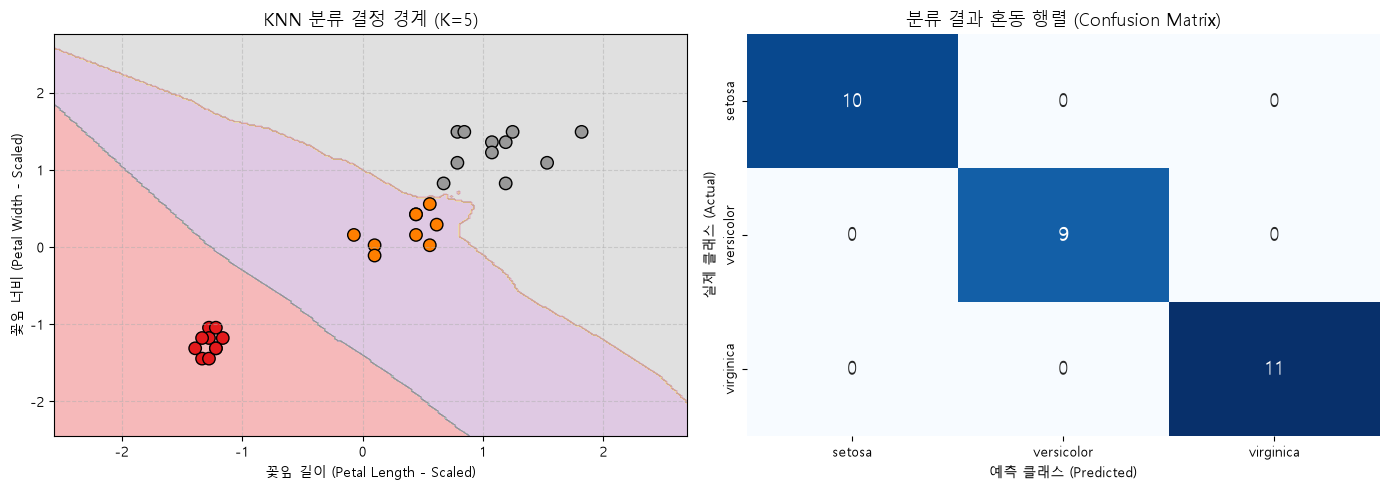

In [6]:
import sys
import platform
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# OS별 한글 폰트 및 마이너스 깨짐 방지 설정
os_name = platform.system()
if os_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif os_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터셋 로드 (2차원 시각화를 위해 대표 특성 2개인 Petal Length, Petal Width 추출)
iris = load_iris()
X = iris.data[:, 2:]  # 꽃잎 길이(Petal Length), 꽃잎 너비(Petal Width)
y = iris.target

# 2. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 피처 스케일링      # 피쳐 스케일링 전처리 작업을 따로 따로 해야함. 일단 분류하고 따로따로 전처리.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. KNN 모델 생성 및 학습 (K=5)
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# 5. 예측
y_pred = knn.predict(X_test_scaled)

# 6. 시각화 (결정 경계 + 혼동 행렬)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [좌측] KNN 결정 경계 (Decision Boundary)
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

print(f'지금 추가 shape:{np.c_[xx.ravel(), yy.ravel()].shape}')
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])  # 테스트값,실제값을 넘겨야함.
print(f'Z={Z.shape}')

print()
Z = Z.reshape(xx.shape)

# 배경 색상 지정 (클래스별 영역)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

# 테스트 데이터 산점도 플롯
scatter = axes[0].scatter(
    X_test_scaled[:, 0], X_test_scaled[:, 1], 
    c=y_test, cmap=plt.cm.Set1, edgecolors='k', s=80
)
axes[0].set_title("KNN 분류 결정 경계 (K=5)", fontsize=13)
axes[0].set_xlabel("꽃잎 길이 (Petal Length - Scaled)")
axes[0].set_ylabel("꽃잎 너비 (Petal Width - Scaled)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# [우측] 혼동 행렬 (Confusion Matrix Heatmap)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=iris.target_names, yticklabels=iris.target_names, 
    ax=axes[1], cbar=False, annot_kws={"size": 14}
)
axes[1].set_title("분류 결과 혼동 행렬 (Confusion Matrix)", fontsize=13)
axes[1].set_xlabel("예측 클래스 (Predicted)")
axes[1].set_ylabel("실제 클래스 (Actual)")

plt.tight_layout()
plt.show()

X=(100, 1)
RMSE (평균 제곱근 오차): 0.1002
R² Score (결정계수): 0.9791


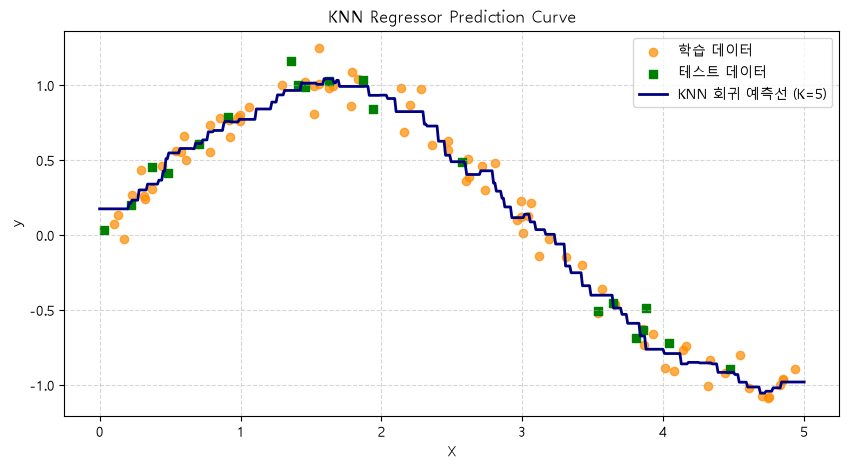

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 비선형 회귀 데이터 생성 (사인 함수 + 노이즈)
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
print(f'X={X.shape}')
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# 2. 학습/테스트 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 피처 스케일링 (거리 기반 모델이므로 필수)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. KNN 회귀 모델 학습 (K=5)
# weights='uniform': 동일 가중치 평균 / weights='distance': 거리가 가까울수록 높은 가중치
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='euclidean')
knn_reg.fit(X_train_scaled, y_train)

# 5. 예측 및 성능 평가
y_pred = knn_reg.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (평균 제곱근 오차): {rmse:.4f}")
print(f"R² Score (결정계수): {r2:.4f}")

# 6. KNN 회귀 예측 곡선 시각화
X_grid = np.linspace(0, 5, 500).reshape(-1, 1)
X_grid_scaled = scaler.transform(X_grid)
y_grid_pred = knn_reg.predict(X_grid_scaled)

plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color='darkorange', label='학습 데이터', alpha=0.7)
plt.scatter(X_test, y_test, color='green', label='테스트 데이터', marker='s')
plt.plot(X_grid, y_grid_pred, color='navy', label='KNN 회귀 예측선 (K=5)', linewidth=2)

plt.title("KNN Regressor Prediction Curve")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()